# Solving Ordinary Differential Equations


## 1. What are Ordinary Differential Equations?

An **Ordinary Differential Equation (ODE)** is a mathematical equation that relates a function of a *single* independent variable to its derivatives. In applied mathematics, physics, and engineering, the independent variable is typically time ($t$), and the function represents the state of a system ($y$).

The standard form of a First-Order Initial Value Problem (IVP) is:

$$
\boxed{\frac{dy}{dt} = f(t, y), \quad y(t_0) = y_0}
$$

Where:

* $t \in [t_0, t_{end}]$ is the independent variable.

* $y \in \mathbb{R}^n$ is the state vector.

* $f: \mathbb{R} \times \mathbb{R}^n \rightarrow \mathbb{R}^n$ is the derivative function (the vector field).

* $y_0$ is the known initial condition.

Higher-order ODEs (e.g., $y'' = -k y$) can always be reduced to a system of first-order ODEs by introducing new variables (e.g., $v = y'$, yielding $y' = v$ and $v' = -k y$). Thus, solving the first-order IVP is the cornerstone of numerical ODE analysis.


## 2. What are the Common Integrators (Time-Steppers)?

Since analytical solutions rarely exist for non-linear systems, we discretize time into steps $t_n = t_0 + n h$ (where $h$ is the step size) and compute approximate solutions $y_n \approx y(t_n)$.

Integrators broadly fall into two structural categories:

1. **Single-Step Methods:** Use only the information from the current step $y_n$ to compute the next step $y_{n+1}$.

   * *Examples:* Euler's method, Runge-Kutta (RK) methods.

2. **Multi-Step Methods:** Use information from several previous steps (e.g., $y_n, y_{n-1}, y_{n-2}$) to compute $y_{n+1}$.

   * *Examples:* Adams-Bashforth, Backward Differentiation Formulas (BDF).

Crucially, we also classify them by *how* $y_{n+1}$ is computed:

* **Explicit Methods:** $y_{n+1}$ is isolated on one side of the equation and computed directly using known values.

* **Implicit Methods:** $y_{n+1}$ appears on *both* sides of the equation, creating a coupled algebraic problem that requires a root-finding algorithm (like Newton-Raphson) to solve.


## 3. Derivation of Fixed-Step Runge-Kutta Integrators

Runge-Kutta (RK) methods are single-step explicit solvers that achieve high-order accuracy without needing historical data or calculating higher analytical derivatives. They do this by evaluating $f(t, y)$ at multiple intermediate stages within a single time step.

### 3.1. Derivation of RK2 (2nd-Order Runge-Kutta)

Let's construct a general 2-stage explicit RK method:

$$
k_1 = f(t_n, y_n)
$$

$$
k_2 = f(t_n + \alpha h, y_n + \beta h k_1)
$$

$$
y_{n+1} = y_n + h(w_1 k_1 + w_2 k_2)
$$

We want to find $\alpha, \beta, w_1, w_2$ such that this matches the Taylor series of $y(t)$ up to $\mathcal{O}(h^2)$.

**Step A: Taylor Expand the Exact Solution**
The exact solution expands as:

$$
y(t_{n+1}) = y_n + h y' + \frac{h^2}{2} y'' + \mathcal{O}(h^3)
$$

Using the multi-variable chain rule on $y' = f(t,y)$, we get $y'' = \frac{\partial f}{\partial t} + \frac{\partial f}{\partial y} y' = f_t + f_y f$. So:

$$
y(t_{n+1}) = y_n + h f + \frac{h^2}{2} (f_t + f f_y) + \mathcal{O}(h^3)
$$

**Step B: Expand the RK2 Formula**
Now, let's Taylor expand $k_2$ in two variables around $(t_n, y_n)$:

$$
k_2 = f(t_n + \alpha h, y_n + \beta h f) \approx f + (\alpha h) f_t + (\beta h f) f_y + \mathcal{O}(h^2)
$$

Substitute $k_1$ and $k_2$ into the update rule:

$$
y_{n+1} = y_n + h \left[ w_1 f + w_2 \left( f + \alpha h f_t + \beta h f f_y \right) \right]
$$

$$
y_{n+1} = y_n + h(w_1 + w_2)f + h^2 w_2 (\alpha f_t + \beta f_y f) + \mathcal{O}(h^3)
$$

**Step C: Match Coefficients**
By equating our Taylor series exact solution to the RK2 expansion, we get a system:

1. $w_1 + w_2 = 1$   (matches $h f$)

2. $w_2 \alpha = 1/2$ (matches $\frac{h^2}{2} f_t$)

3. $w_2 \beta = 1/2$  (matches $\frac{h^2}{2} f f_y$)

This is an underdetermined system (3 equations, 4 unknowns). Thus, there is an infinite family of RK2 methods!

* If $\alpha = 1$, then $\beta = 1, w_2 = 1/2, w_1 = 1/2$. This is **Heun's Method**.

* If $\alpha = 1/2$, then $\beta = 1/2, w_2 = 1, w_1 = 0$. This is the **Midpoint Method**.

### 3.2. Derivation of RK4 (The Classic 4th-Order Method)

Deriving RK4 purely via Taylor series is excruciatingly tedious, requiring matching of 8 equations for 13 variables up to $\mathcal{O}(h^4)$. However, we can elegantly motivate RK4 by connecting it to **Simpson's 1/3 Rule** for numerical integration.

Recall the integral form of the ODE:

$$
y(t_{n+1}) - y(t_n) = \int_{t_n}^{t_n+h} f(\tau, y(\tau)) d\tau
$$

Simpson's rule approximates this integral using the start, midpoint, and end of the interval:

$$
y_{n+1} \approx y_n + \frac{h}{6} \left[ f(t_n) + 4f(t_n + h/2) + f(t_n + h) \right]
$$

To implement this dynamically, we need approximations for the intermediate $y$ values to plug into $f$:

1. **Start:** $k_1 = f(t_n, y_n)$.

2. **Midpoint Predictor 1:** Use $k_1$ to estimate the midpoint $y$:

   $$
   k_2 = f(t_n + \frac{h}{2}, y_n + \frac{h}{2} k_1)
   $$

3. **Midpoint Predictor 2:** Use $k_2$ to get a *better* estimate at the midpoint:

   $$
   k_3 = f(t_n + \frac{h}{2}, y_n + \frac{h}{2} k_2)
   $$

4. **End Predictor:** Use $k_3$ to step all the way to $t_n + h$:

   $$
   k_4 = f(t_n + h, y_n + h k_3)
   $$

Now, plug these back into Simpson's rule, splitting the middle term $4f(t_n + h/2)$ into two parts using both $k_2$ and $k_3$:

$$
\boxed{y_{n+1} = y_n + \frac{h}{6} (k_1 + 2k_2 + 2k_3 + k_4)}
$$

This formulation magically cancels all error terms up to $\mathcal{O}(h^4)$, forming the standard, universally beloved RK4 method.


## 4. Derivation of Adaptive RK4 Integrators

Fixed-step solvers are very inefficient. If the solution is volatile, we need a tiny $h$. If it is smooth, a tiny $h$ wastes computation. **Adaptive step-sizing** dynamically changes $h$ based on an estimate of the local error.

The classical way to adapt the step size for RK4 is **Step Doubling** (based on Richardson Extrapolation).

### 4.1. Error Estimation via Step Doubling

Suppose we take a step of size $h$ from $t_n$ to $t_{n+h}$. Let the exact analytical solution be $Y(t_{n+h})$. Because RK4 is a 4th-order method, the local truncation error scales with $h^5$. Let $y_1$ be the value computed using one full step $h$:

$$
y_1 = Y(t_{n+h}) + C h^5 + \mathcal{O}(h^6)
$$

*(Where* $C$ *is an unknown constant related to the 5th derivative of the solution).*

Now, let's compute the same target point by taking **two half-steps** of size $h/2$. Let this result be $y_2$:

$$
y_2 = Y(t_{n+h}) + 2 \times C \left(\frac{h}{2}\right)^5 + \mathcal{O}(h^6)
$$

$$
= Y(t_{n+h}) + C \frac{h^5}{16}
$$

We can isolate the error term by subtracting the two equations:

$$
y_1 - y_2 \approx C h^5 - C \frac{h^5}{16} = \frac{15}{16} C h^5
$$

$$
\implies C h^5 \approx \frac{16}{15} (y_1 - y_2)
$$

The error present in our *better* estimate ($y_2$) is $C \frac{h^5}{16}$. Substituting $Ch^5$ gives us our **Local Truncation Error estimate (**$e$**)**:

$$
e \approx \frac{y_1 - y_2}{15}
$$

### 4.2. Step Size Adjustment

We compare this estimated error $e$ against a user-defined tolerance $\epsilon$. Since the error scales as $h^5$, if we want to change our step size to a new $h_{new}$ such that the new error exactly equals $\epsilon$, we set up the ratio:

$$
\frac{\epsilon}{|e|} = \frac{h_{new}^5}{h^5}
$$

Solving for the new step size yields the update law:

$$
\boxed{h_{new} = h \left| \frac{\epsilon}{e} \right|^{1/5}}
$$

*(Note: Modern solvers like `ode45` use Embedded Runge-Kutta pairs like Dormand-Prince, calculating a 4th and 5th order estimate simultaneously using the same* $k$ *evaluations to get* $e$*, avoiding the cost of taking three steps!)*


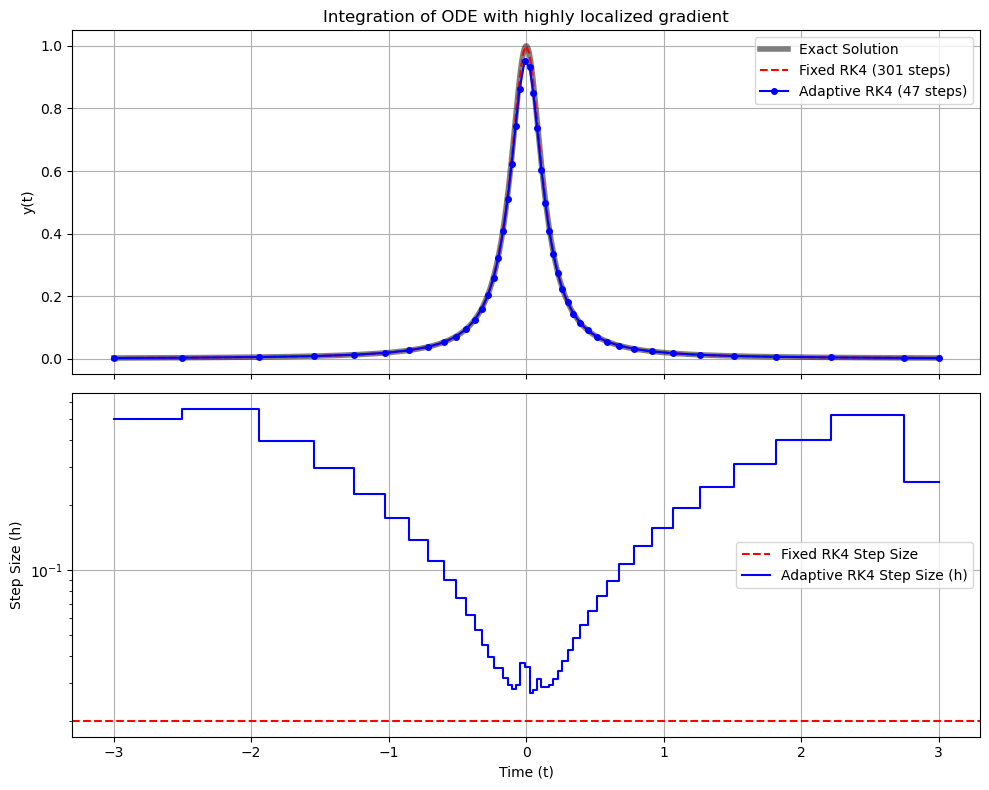

Fixed RK4 Steps required: 301
Adaptive RK4 Steps required: 47
Notice how the Adaptive solver takes massive steps on the edges and tiny steps at the peak!


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# 1. The ODE Problem
# We choose an ODE whose solution has a very sharp peak at t = 0 but is
# otherwise flat.
# ODE: dy/dt = -100 * t * y^2
# Exact Solution: y(t) = 1 / (1 + 50 * t^2)
# ==============================================================================


def f(t, y):
    return -100.0 * t * (y**2)


def exact_solution(t):
    return 1.0 / (1.0 + 50.0 * (t**2))


# ==============================================================================
# 2. The RK4 Core Step
# ==============================================================================


def rk4_step(f, t, y, h):
    """Performs a single standard RK4 step."""
    k1 = f(t, y)
    k2 = f(t + h / 2.0, y + (h / 2.0) * k1)
    k3 = f(t + h / 2.0, y + (h / 2.0) * k2)
    k4 = f(t + h, y + h * k3)
    return y + (h / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)


# ==============================================================================
# 3. Fixed-Step RK4 Integrator
# ==============================================================================


def integrate_fixed_rk4(t_span, y0, h):
    t_vals = [t_span[0]]
    y_vals = [y0]

    t = t_span[0]
    y = y0

    while t < t_span[1]:
        # Ensure we don't step past the end time
        if t + h > t_span[1]:
            h = t_span[1] - t

        y = rk4_step(f, t, y, h)
        t += h

        t_vals.append(t)
        y_vals.append(y)

    return np.array(t_vals), np.array(y_vals)


# ==============================================================================
# 4. Adaptive RK4 Integrator (Using Step Doubling)
# ==============================================================================


def integrate_adaptive_rk4(t_span, y0, tol, initial_h):
    t_vals = [t_span[0]]
    y_vals = [y0]
    h_vals = [initial_h]  # To track step sizes

    t = t_span[0]
    y = y0
    h = initial_h

    while t < t_span[1]:
        # Prevent overshooting the end time
        if t + h > t_span[1]:
            h = t_span[1] - t

        # --- Step Doubling Error Estimation ---
        # 1. Take one full step of size h
        y1 = rk4_step(f, t, y, h)

        # 2. Take two half-steps of size h/2
        y_half = rk4_step(f, t, y, h / 2.0)
        y2 = rk4_step(f, t + h / 2.0, y_half, h / 2.0)

        # 3. Compute local truncation error estimate
        e = abs(y1 - y2) / 15.0

        # Prevent division by zero if error is exactly 0
        e = max(e, 1e-15)

        # --- Step Acceptance and Adaptation ---
        if e <= tol:
            # Error is acceptable, advance time and save the step
            t += h
            y = y2  # Use the better estimate!
            t_vals.append(t)
            y_vals.append(y)
            h_vals.append(h)

        # Calculate new step size (Section 4.2 of notes)
        # Safety factor of 0.9 prevents bouncing around the tolerance
        h_new = 0.9 * h * (tol / e) ** 0.2

        # Limit how fast step size can grow or shrink for stability
        h = min(max(h_new, 0.1 * h), 5.0 * h)

    return np.array(t_vals), np.array(y_vals), np.array(h_vals)


# ==============================================================================
# 5. Execution and Plotting
# ==============================================================================

if __name__ == "__main__":
    t_span = (-3.0, 3.0)
    y0 = exact_solution(t_span[0])

    # 1. Run Fixed Step RK4
    # Needs a small h to capture the peak at t=0 accurately
    h_fixed = 0.02
    t_fix, y_fix = integrate_fixed_rk4(t_span, y0, h_fixed)

    # 2. Run Adaptive RK4
    tol = 1e-6
    initial_h = 0.5  # Start with a huge step
    t_adapt, y_adapt, h_adapt = integrate_adaptive_rk4(t_span, y0, tol, initial_h)

    # --- Plotting Results ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

    # Top Plot: Solutions
    t_fine = np.linspace(t_span[0], t_span[1], 1000)
    ax1.plot(
        t_fine, exact_solution(t_fine), "k-", label="Exact Solution", alpha=0.5, lw=4
    )
    ax1.plot(t_fix, y_fix, "r--", label=f"Fixed RK4 ({len(t_fix)} steps)")
    ax1.plot(
        t_adapt,
        y_adapt,
        "bo-",
        label=f"Adaptive RK4 ({len(t_adapt)} steps)",
        markersize=4,
    )

    ax1.set_ylabel("y(t)")
    ax1.set_title("Integration of ODE with highly localized gradient")
    ax1.legend()
    ax1.grid(True)

    # Bottom Plot: Step Sizes
    # For fixed, the step size is constant.
    ax2.axhline(h_fixed, color="r", linestyle="--", label="Fixed RK4 Step Size")

    # We plot the step size USED to get TO a given time t.
    ax2.step(t_adapt, h_adapt, "b-", where="pre", label="Adaptive RK4 Step Size (h)")

    ax2.set_xlabel("Time (t)")
    ax2.set_ylabel("Step Size (h)")
    ax2.set_yscale("log")
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

    print(f"Fixed RK4 Steps required: {len(t_fix)}")
    print(f"Adaptive RK4 Steps required: {len(t_adapt)}")
    print(
        "Notice how the Adaptive solver takes massive steps on the edges and tiny steps at the peak!"
    )

## 5.  Stiff Differential Equations

A **Stiff ODE** is a system containing vastly different timescales—for example, a chemical reaction where one substance decays in milliseconds and another in hours. Mathematically, the Jacobian $\frac{\partial f}{\partial y}$ has eigenvalues with large negative real parts.

If we are forced to use explicit time-steppers for stiff equations, **we become bounded by Stability, not Accuracy.** Let's derive the stability constraint using the linear test equation $y' = \lambda y$, where $\lambda < 0$. Using the simplest explicit method (Forward Euler):

$$
y_{n+1} = y_n + h \lambda y_n = (1 + h\lambda) y_n
$$

The term $(1 + h\lambda)$ is the **amplification factor**. For the numerical solution to decay (as the true solution $e^{\lambda t}$ does) and not explode to infinity, we must require:

$$
|1 + h\lambda| < 1 \implies -2 < h\lambda < 0
$$

Since $\lambda = -|\lambda|$, the stability condition becomes:

$$
h < \frac{2}{|\lambda|}
$$

**Consequences of Stiffness on Explicit Methods:**
If you *must* use explicit timestepping on a stiff ODE:

1. **Micro-stepping:** You are forced to use an artificially tiny time step governed by the fastest, most stable transient in your system, even after that transient has died out.

2. **Adaptive Paralysis:** An adaptive RK4 solver will detect the incipient instability and aggressively crush $h$ down to a microscopic level. It will "solve" the problem, but might take millions of unnecessary steps.

This profound limitation is exactly why we derive **Implicit Time-Steppers**.


## 6. Derivation of Implicit Time-Steppers

To formally address stiffness, one must examine the absolute stability of a numerical method via Dahlquist's linear test equation:

$$
\boxed{y' = \lambda y, \quad \lambda \in \mathbb{C}, \quad \text{Re}(\lambda) < 0}
$$

When we apply any numerical integrator to this standard linear test equation, the method reduces to a simple recursive formula: the next step ($y_{n+1}$) is just the current step ($y_n$) multiplied by some factor:

$$
y_{n+1} = R(z) y_n
$$

This factor is the **stability function**, denoted as $R(z)$, where $z = h\lambda$. Because the exact analytical solution to $y' = \lambda y$ is $y(t) = y_0 e^{\lambda t}$, the exact solution gets multiplied by $e^{h\lambda}$ (or $e^z$) at each step of size $h$. Therefore, $R(z)$ is essentially the numerical method's approximation of the exponential function $e^z$.

The *region of absolute stability*, $\mathcal{S}$, is defined as the set of all $z$ in the complex plane for which the numerical solution strictly decays, mirroring the analytic solution $y(t) = y_0 e^{\lambda t}$:

$$
\mathcal{S} = \{ z \in \mathbb{C} \mid |R(z)| < 1 \}
$$

A numerical integrator is defined as **A-stable** if its stability region encompasses the entire left half of the complex plane, i.e., $\mathbb{C}^- \subset \mathcal{S}$. This rigorously guarantees that the step size $h$ is entirely unrestricted by stability constraints, regardless of the magnitude of $\text{Re}(\lambda)$.

By Dahlquist's Second Barrier, no explicit Runge-Kutta or explicit linear multistep method can be A-stable. Explicit methods inherently possess polynomial stability functions, $P(z)$, which inevitably diverge as $|z| \to \infty$, thereby restricting $\mathcal{S}$ to a strictly bounded region near the origin. Consequently, evaluating the vector field $f(t,y)$ solely at current or past states is mathematically insufficient for integrating stiff systems.

To construct an A-stable method, the stability function $R(z)$ must be a rational function capable of remaining bounded (with $|R(z)| < 1$) as $\text{Re}(z) \to -\infty$. This mathematically necessitates an **implicit** formulation, where the evaluation of the derivative $f(t_{n+1}, y_{n+1})$ recursively couples the unknown future state into the step computation, generating the requisite rational algebraic structure in the stability domain.

### 6.1. The Backward Euler Method (1st Order Implicit)

The simplest implicit method can be derived via a backwards Taylor series expansion. Instead of expanding $y(t_{n+1})$ around $t_n$, we expand $y(t_n)$ around the future point $t_{n+1}$:

$$
y(t_n) = y(t_{n+1} - h) = y(t_{n+1}) - h y'(t_{n+1}) + \frac{h^2}{2} y''(t_{n+1}) - \mathcal{O}(h^3)
$$

Truncate after the linear term and rearrange to solve for $y(t_{n+1})$:

$$
y(t_{n+1}) \approx y(t_n) + h y'(t_{n+1})
$$

Substitute the ODE $y'(t_{n+1}) = f(t_{n+1}, y_{n+1})$:

$$
\boxed{y_{n+1} = y_n + h f(t_{n+1}, y_{n+1})}
$$

This is the **Backward Euler Method**. Notice the core difficulty: $y_{n+1}$ is on both the left and right sides of the equation. If $f$ is non-linear, we cannot simply isolate $y_{n+1}$. We must use a root-finding algorithm (like Newton-Raphson) at every single time step to find the $y_{n+1}$ that satisfies this equation.

**Why do this? Look at stability:**
Apply the test equation $y' = \lambda y$ ($\lambda < 0$):

$$
y_{n+1} = y_n + h \lambda y_{n+1}
$$

$$
y_{n+1}(1 - h\lambda) = y_n \implies y_{n+1} = \left( \frac{1}{1 - h\lambda} \right) y_n
$$

The amplification factor is $\frac{1}{1 - h\lambda}$. Since $\lambda$ is negative, $h\lambda$ is negative, making the denominator $> 1$. Thus, $\left| \frac{1}{1 - h\lambda} \right| < 1$ for **ANY** positive step size $h$. The method is unconditionally stable!

### 6.2. The Trapezoidal Rule / Crank-Nicolson (2nd Order Implicit)

Backward Euler is highly stable but only 1st-order accurate. We can derive a 2nd-order implicit method by returning to the fundamental theorem of calculus:

$$
y(t_{n+1}) - y(t_n) = \int_{t_n}^{t_{n+1}} f(\tau, y(\tau)) d\tau
$$

Instead of evaluating the integral using just the left endpoint (Forward Euler) or the right endpoint (Backward Euler), we approximate the integral using the **Trapezoidal Rule**:

$$
\int_{a}^{b} g(\tau) d\tau \approx \frac{b-a}{2} \left[ g(a) + g(b) \right]
$$

Applying this to our ODE integral gives:

$$
\boxed{y_{n+1} = y_n + \frac{h}{2} \left[ f(t_n, y_n) + f(t_{n+1}, y_{n+1}) \right]}
$$

Substitute the test equation:

$$
y_{n+1} = y_n + \frac{h}{2} (\lambda y_n + \lambda y_{n+1})
$$

Group the $y_{n+1}$ terms on the left and $y_n$ terms on the right:

$$
y_{n+1} \left(1 - \frac{h\lambda}{2}\right) = y_n \left(1 + \frac{h\lambda}{2}\right)
$$

$$
y_{n+1} = \left( \frac{1 + \frac{h\lambda}{2}}{1 - \frac{h\lambda}{2}} \right) y_n
$$

Substituting $z = h\lambda$:

$$
\boxed{R(z) = \frac{1 + z/2}{1 - z/2}}
$$

Notice how explicit methods (like Forward Euler and RK4) always result in a polynomial $R(z)$, while implicit methods result in a rational fraction $R(z)$, which is what allows them to remain bounded (stable) even when step sizes get very large!

This is the **Implicit Trapezoidal Method** (often called Crank-Nicolson in PDE contexts). It averages the explicit and implicit Euler steps.

* It is $\mathcal{O}(h^2)$ accurate.

* It remains A-stable (unconditionally stable for stable linear systems).

* Like Backward Euler, it requires solving a non-linear algebraic system for $y_{n+1}$ at every step, making each individual step computationally expensive, but allowing for massive step sizes $h$ when traversing stiff regions.


--- Integrating Stiff ODE: lambda = -1000 ---
Starting Adaptive RK4 (Explicit)...
Adaptive RK4 Finished in 0.068 seconds.
Total Steps taken by Explicit RK4: 1868

Starting Crank-Nicolson (Implicit) with Fixed h = 0.5...
Crank-Nicolson Finished in 0.000 seconds.
Total Steps taken by Implicit CN: 21


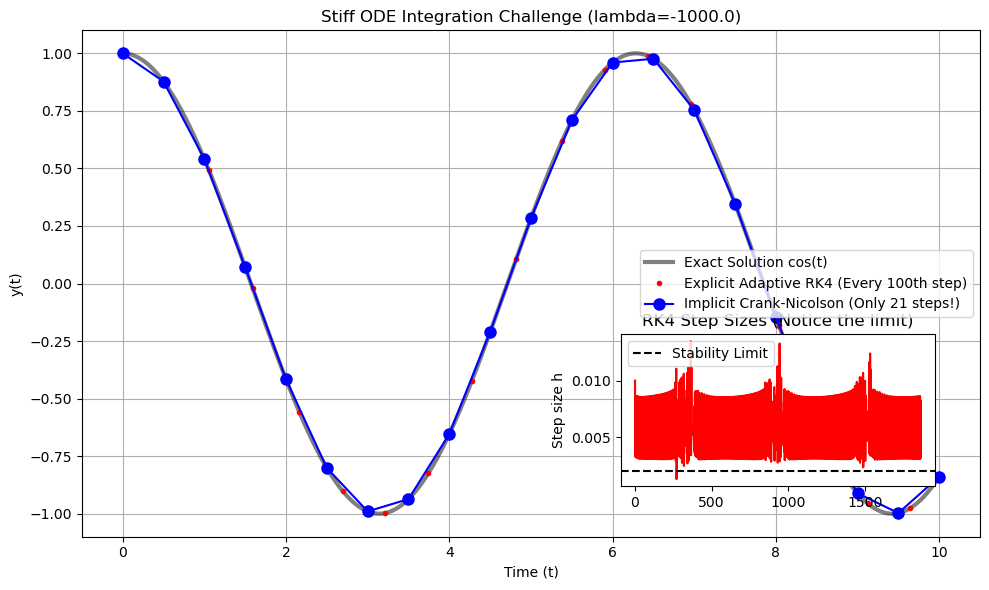


Takeaway:
The explicit solver was forced to take steps of h ~= 0.002 just to remain stable.
The implicit solver bounded right over the stiffness taking steps of h = 0.5!


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time

# ==============================================================================
# 1. The Stiff ODE Problem
# We use a linear system with an extremely fast transient.
# ODE: dy/dt = lambda * (y - cos(t)) - sin(t)
# Exact Solution: y(t) = cos(t)
#
# The analytical transient solution goes like e^(lambda * t).
# If lambda = -1000, the transient dies almost instantly, but explicitly
# integrating it requires h < 2/|lambda| = 0.002 for the ENTIRE duration!
# ==============================================================================

LAMBDA = -1000.0


def f_stiff(t, y):
    return LAMBDA * (y - np.cos(t)) - np.sin(t)


def exact_solution(t):
    return np.cos(t)


# ==============================================================================
# 2. Adaptive RK4 (Explicit)
# We reuse the exact same explicit adaptive solver from the previous script.
# ==============================================================================


def rk4_step(f, t, y, h):
    k1 = f(t, y)
    k2 = f(t + h / 2.0, y + (h / 2.0) * k1)
    k3 = f(t + h / 2.0, y + (h / 2.0) * k2)
    k4 = f(t + h, y + h * k3)
    return y + (h / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)


def integrate_adaptive_rk4(t_span, y0, tol, initial_h):
    t_vals = [t_span[0]]
    y_vals = [y0]

    t = t_span[0]
    y = y0
    h = initial_h

    while t < t_span[1]:
        if t + h > t_span[1]:
            h = t_span[1] - t

        y1 = rk4_step(f_stiff, t, y, h)
        y_half = rk4_step(f_stiff, t, y, h / 2.0)
        y2 = rk4_step(f_stiff, t + h / 2.0, y_half, h / 2.0)

        e = abs(y1 - y2) / 15.0
        e = max(e, 1e-15)

        if e <= tol:
            t += h
            y = y2
            t_vals.append(t)
            y_vals.append(y)

        # The adaptive step size will be mathematically capped by the
        # stability limit (h ~= 0.002) rather than the accuracy limit!
        h_new = 0.9 * h * (tol / e) ** 0.2
        h = min(max(h_new, 0.1 * h), 5.0 * h)

    return np.array(t_vals), np.array(y_vals)


# ==============================================================================
# 3. Crank-Nicolson (Implicit)
#
# Formula: y_{n+1} = y_n + (h/2) * [ f(t_n, y_n) + f(t_{n+1}, y_{n+1}) ]
# Because our ODE is linear in y, we don't need Newton-Raphson. We can
# algebraically solve for y_{n+1} directly!
# ==============================================================================


def crank_nicolson_step(t, y, h):
    # f(t,y) = L*(y - cos(t)) - sin(t)
    # y_{n+1} = y_n + (h/2) * [ L(y_n - cos(tn)) - sin(tn) + L(y_{n+1} - cos(tn+1)) - sin(tn+1) ]
    #
    # Move y_{n+1} to left side:
    # y_{n+1} * (1 - h*L/2) = y_n + (h/2)*[ L*y_n - L*cos(tn) - sin(tn) - L*cos(tn+1) - sin(tn+1) ]

    tn = t
    tn1 = t + h
    yn = y
    L = LAMBDA

    term1 = L * yn - L * np.cos(tn) - np.sin(tn)
    term2 = -L * np.cos(tn1) - np.sin(tn1)

    RHS = yn + (h / 2.0) * (term1 + term2)
    LHS_factor = 1.0 - (h * L / 2.0)

    y_next = RHS / LHS_factor
    return y_next


def integrate_implicit_cn(t_span, y0, h):
    t_vals = [t_span[0]]
    y_vals = [y0]

    t = t_span[0]
    y = y0

    while t < t_span[1]:
        if t + h > t_span[1]:
            h = t_span[1] - t

        y = crank_nicolson_step(t, y, h)
        t += h

        t_vals.append(t)
        y_vals.append(y)

    return np.array(t_vals), np.array(y_vals)


# ==============================================================================
# 4. Execution and Plotting
# ==============================================================================

if __name__ == "__main__":
    t_span = (0.0, 10.0)
    y0 = 1.0  # Exact condition y(0) = cos(0) = 1

    print("--- Integrating Stiff ODE: lambda = -1000 ---")

    # 1. Run Explicit Adaptive RK4
    tol = 1e-4
    initial_h = 0.1  # We try to give it a generous initial step
    print("Starting Adaptive RK4 (Explicit)...")
    t0_rk = time.time()
    t_rk4, y_rk4 = integrate_adaptive_rk4(t_span, y0, tol, initial_h)
    t1_rk = time.time()
    print(f"Adaptive RK4 Finished in {t1_rk - t0_rk:.3f} seconds.")
    print(f"Total Steps taken by Explicit RK4: {len(t_rk4)}")

    # 2. Run Implicit Crank-Nicolson
    # Because it is A-stable, we can pick a HUGE step size purely based on
    # how smooth cos(t) is, completely ignoring the stiffness (lambda).
    h_implicit = 0.5
    print(f"\nStarting Crank-Nicolson (Implicit) with Fixed h = {h_implicit}...")
    t0_cn = time.time()
    t_cn, y_cn = integrate_implicit_cn(t_span, y0, h_implicit)
    t1_cn = time.time()
    print(f"Crank-Nicolson Finished in {t1_cn - t0_cn:.3f} seconds.")
    print(f"Total Steps taken by Implicit CN: {len(t_cn)}")

    # --- Plotting Results ---
    plt.figure(figsize=(10, 6))

    t_fine = np.linspace(t_span[0], t_span[1], 1000)
    plt.plot(
        t_fine,
        exact_solution(t_fine),
        "k-",
        lw=3,
        label="Exact Solution cos(t)",
        alpha=0.5,
    )

    # We plot dots to show exactly where the solver took a step
    plt.plot(
        t_rk4[::100],
        y_rk4[::100],
        "r.",
        label="Explicit Adaptive RK4 (Every 100th step)",
    )
    plt.plot(
        t_cn,
        y_cn,
        "bo-",
        label=f"Implicit Crank-Nicolson (Only {len(t_cn)} steps!)",
        markersize=8,
    )

    plt.title(f"Stiff ODE Integration Challenge (lambda={LAMBDA})")
    plt.xlabel("Time (t)")
    plt.ylabel("y(t)")
    plt.legend()
    plt.grid(True)

    # Inset axis to show what explicit is doing
    axins = plt.gca().inset_axes([0.6, 0.1, 0.35, 0.3])
    axins.plot(np.diff(t_rk4), "r-")
    axins.set_title("RK4 Step Sizes (Notice the limit)")
    axins.set_ylabel("Step size h")
    axins.axhline(2.0 / abs(LAMBDA), color="k", linestyle="--", label="Stability Limit")
    axins.legend()

    plt.tight_layout()
    plt.show()

    print("\nTakeaway:")
    print(
        f"The explicit solver was forced to take steps of h ~= {2.0/abs(LAMBDA)} just to remain stable."
    )
    print(
        f"The implicit solver bounded right over the stiffness taking steps of h = {h_implicit}!"
    )